In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
# Load NAV history dataset

nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Display first 5 rows
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
# Convert date column to datetime format
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Display first 5 rows again
nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [5]:
# Calculate daily percentage return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display the first 10 rows
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [6]:
# Remove missing values
returns = nav["daily_return"].dropna()

# Calculate 95% Value at Risk
var_95 = np.percentile(returns, 5)

print("95% Value at Risk (VaR):", round(var_95 * 100, 2), "%")

95% Value at Risk (VaR): -1.63 %


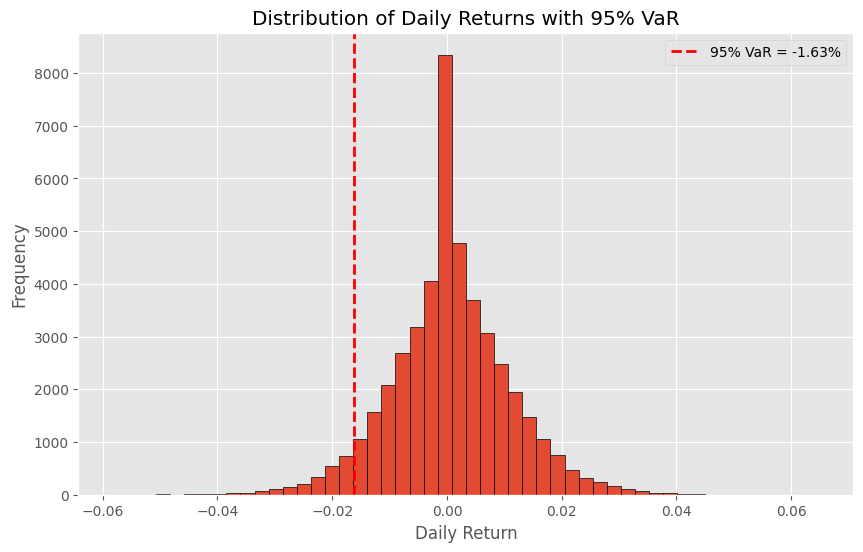

In [7]:
# Plot histogram of daily returns

plt.figure(figsize=(10,6))

plt.hist(returns, bins=50, edgecolor="black")

plt.axvline(
    var_95,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"95% VaR = {var_95:.2%}"
)

plt.title("Distribution of Daily Returns with 95% VaR")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [8]:
# Load investor transactions

investors = pd.read_csv("../data/raw/08_investor_transactions.csv")

# Display first 5 rows
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [9]:
# Convert transaction_date to datetime

investors["transaction_date"] = pd.to_datetime(investors["transaction_date"])

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [10]:
# Create cohort month

investors["cohort_month"] = investors["transaction_date"].dt.to_period("M")

investors[["transaction_date", "cohort_month"]].head()

,transaction_date,cohort_month
0,2024-01-01,2024-01
1,2024-01-01,2024-01
2,2024-01-01,2024-01
3,2024-01-01,2024-01
4,2024-01-01,2024-01


In [11]:
# Count investors by cohort

cohort = investors.groupby("cohort_month")["investor_id"].nunique().reset_index()

cohort.columns = ["Month", "Unique Investors"]

cohort

,Month,Unique Investors
0,2024-01,1577
1,2024-02,1530
2,2024-03,1592
3,2024-04,1558
4,2024-05,1551
5,2024-06,1615
6,2024-07,1589
7,2024-08,1601
8,2024-09,1503
9,2024-10,1566


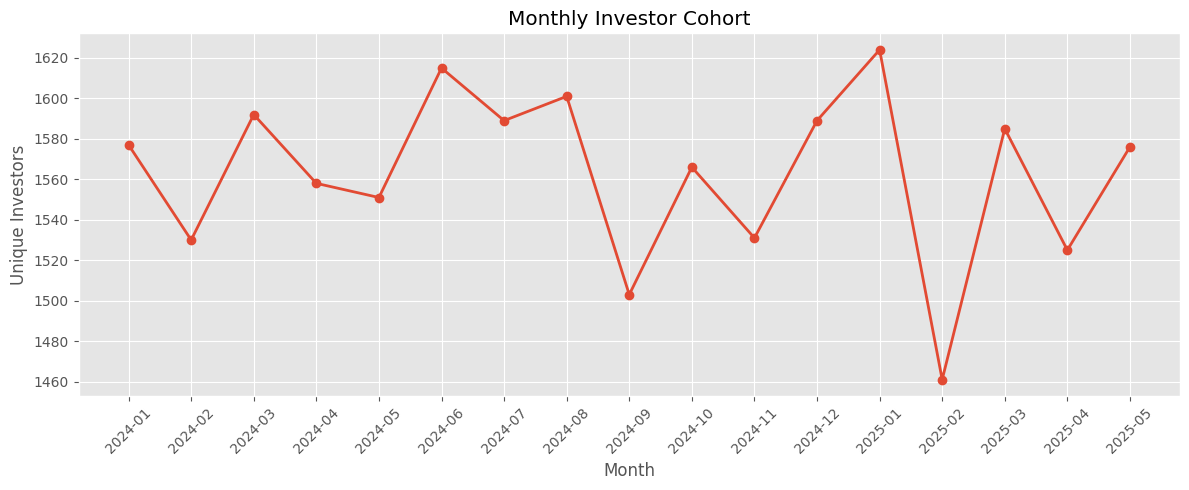

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    cohort["Month"].astype(str),
    cohort["Unique Investors"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Investor Cohort")
plt.xlabel("Month")
plt.ylabel("Unique Investors")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Load performance dataset

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [14]:
# Create Recommendation Score

performance["recommendation_score"] = (
    performance["return_3yr_pct"] * 0.5 +
    performance["sharpe_ratio"] * 20 -
    performance["std_dev_ann_pct"] * 0.3
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,recommendation_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,19.580
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,17.650
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,22.995
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,22.670
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,32.235


In [15]:
top10 = performance.sort_values(
    by="recommendation_score",
    ascending=False
).head(10)

top10[
    [
        "scheme_name",
        "fund_house",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "recommendation_score"
    ]
]

,scheme_name,fund_house,category,return_3yr_pct,sharpe_ratio,recommendation_score
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,7.68,7.68,157.290
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,6.18,6.18,126.540
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,5.14,5.14,105.220
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,7.37,1.84,39.285
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,6.07,1.52,32.235
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,5.31,1.33,28.055
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,14.84,1.06,24.420
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.81,1.06,24.405
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.41,1.03,23.605
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,0.94,22.995


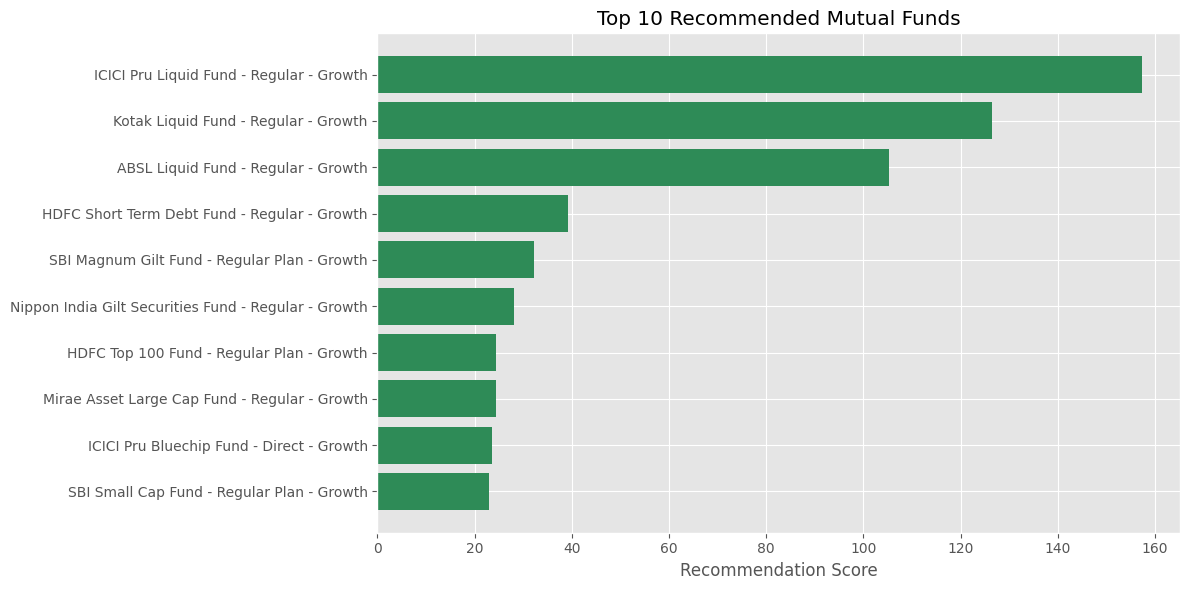

In [16]:
plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["recommendation_score"],
    color="seagreen"
)

plt.title("Top 10 Recommended Mutual Funds")
plt.xlabel("Recommendation Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
top10.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


# Key Findings

- Calculated daily returns for all mutual fund schemes.
- Estimated 95% Value at Risk (VaR) using historical returns.
- Created a VaR distribution chart.
- Performed Monthly Investor Cohort Analysis.
- Designed a Recommendation Score using:
  - 3-Year Return
  - Sharpe Ratio
  - Annual Volatility
- Generated Top 10 Recommended Mutual Funds.
- Exported recommendation results to CSV.

# Conclusion

Advanced analytics provides investors with risk measurement, return analysis, and a systematic recommendation framework for selecting high-performing mutual funds. These techniques improve investment decision-making using quantitative metrics rather than subjective judgment.

In [18]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print("Total NAV Records:", len(nav))

Total NAV Records: 46000


In [19]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

print("Total Investor Transactions:", len(transactions))

Total Investor Transactions: 32778


In [20]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")

print("Total Mutual Fund Schemes:", len(funds))

Total Mutual Fund Schemes: 40


In [21]:
print("Fund Houses:", funds["fund_house"].nunique())

Fund Houses: 10


In [22]:
print("Categories:", funds["category"].nunique())

Categories: 2


In [23]:
print("States:", transactions["state"].nunique())

States: 12


In [24]:
print("Unique Investors:", transactions["investor_id"].nunique())

Unique Investors: 5000
